## Format of PCA Document - 
1. Loading in relevant libraries and Datasets
2. Scaling (Standard Scaler)
3. Applying PCA

------------Graphs------------

4. Scree Plot (Bar-Style)
5. Scree Plot (Line-Style: Elbow Method)
6. Scree Plot (Line-Style: Kaister Method)
7. Decomposition Plot (Loadings df created)
8. PC1 vs PC2 Scatter Plot
9. PC1 & PC2 Bi-Plot

------------HandOff------------

10. Hand off dataframe created

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt  # Essential for Scree Plot and Scatters
import seaborn as sns

In [ ]:

numeric_cols = ['Exposure', 'VehPower', 'VehAge', 'DrivAge', 'BonusMalus', 'Density']
#include encoding and shi for categorical columns later

# File paths
TESTPATH = "../data/raw/claims_train.csv"
TRAINPATH = "../data/raw/claims_test.csv"

# Load the train dataset
df = pd.read_csv(TRAINPATH)
df_test = pd.read_csv(TESTPATH)


In [6]:
def apply_standardization(train_df, test_df, numeric_cols):
    """
    Standardizes numeric features using Z-score scaling.
    Ensures mean=0 and std=1.
    """
    scaler = StandardScaler()
    
    # Copy to protect original data
    train_scaled = train_df.copy()
    test_scaled = test_df.copy()
    
    # Fit & Transform train; only Transform test (prevents leakage)
    train_scaled[numeric_cols] = scaler.fit_transform(train_df[numeric_cols])
    test_scaled[numeric_cols] = scaler.transform(test_df[numeric_cols])
    
    return train_scaled, test_scaled, scaler

train_scaled, test_scaled, scaler_obj = apply_standardization(df, df_test, numeric_cols)


In [22]:
# 1. Initialize and fit PCA
pca = PCA()
X_train_pca = pca.fit_transform(train_scaled[numeric_cols])
print( X_train_pca.shape)

# 2. Analysis of Variance
exp_var = pca.explained_variance_ratio_
cum_var = np.cumsum(exp_var)

# 3. Find the 95% threshold (CORRECTED LINE)
# Use 0.95 for 95% variance
n_95 = np.argmax(cum_var >= 0.95) + 1

print(f"95% Variance reached at: {n_95} components")

(135603, 6)
95% Variance reached at: 6 components


95% Variance reached at: 3 components


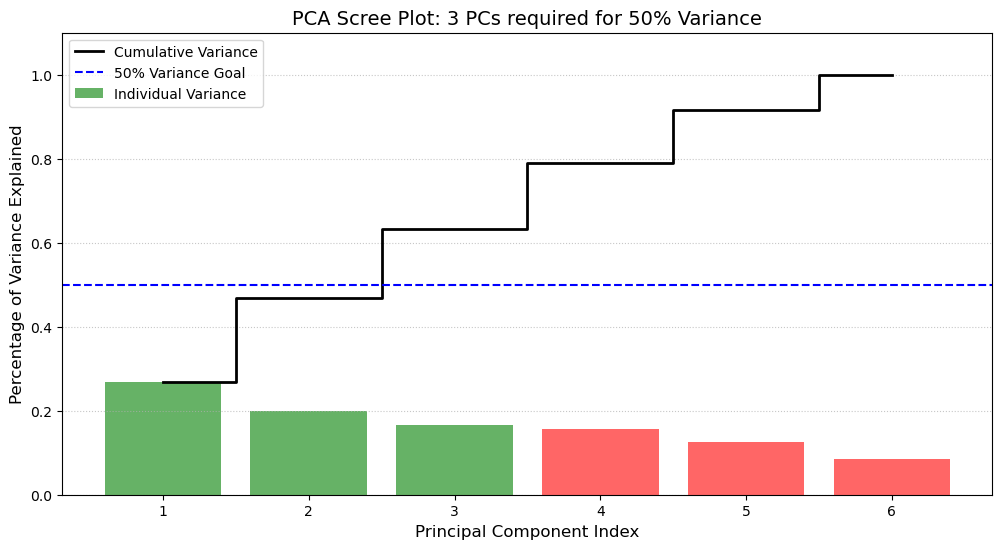

In [ ]:
"""
# testing scree plot 50 percent cut off
# 1. Initialize and fit PCA
pca = PCA()
X_train_pca = pca.fit_transform(train_scaled[numeric_cols])

# 2. Analysis of Variance
exp_var = pca.explained_variance_ratio_
cum_var = np.cumsum(exp_var)

# 3. Find the 50% threshold (CORRECTED LINE)
# Use 0.5 for 50% variance
n_50 = np.argmax(cum_var >= 0.5) + 1

print(f"95% Variance reached at: {n_50} components")
#::::::::::::::::::::::::::::::::::::::::::::::::::::#
#Scree Plot
# 1. Determine how many PCs to show (up to 10 or max available)
n_display = min(10, len(exp_var))

# 2. Find the index where cumulative variance first hits 95%
# np.argmax returns the first index where the condition is True
n_95 = np.argmax(cum_var >= 0.5) + 1

# 3. Create a list of colors: Green for those within 95%, Red for the rest
colors = ['green' if i < n_50 else 'red' for i in range(n_display)]

# 4. Plotting
plt.figure(figsize=(12, 6))

# Plot the bars with our custom color list
plt.bar(range(1, n_display + 1), exp_var[:n_display], 
        color=colors, alpha=0.6, label='Individual Variance')

# Plot the cumulative staircase
plt.step(range(1, n_display + 1), cum_var[:n_display], 
         where='mid', label='Cumulative Variance', color='black', linewidth=2)

# Add the 50% threshold line
plt.axhline(y=0.5, color='blue', linestyle='--', label='50% Variance Goal')

# Labels and Title
plt.title(f"PCA Scree Plot: {n_50} PCs required for 50% Variance", fontsize=14)
plt.xlabel("Principal Component Index", fontsize=12)
plt.ylabel("Percentage of Variance Explained", fontsize=12)
plt.xticks(range(1, n_display + 1)) # Ensure 1, 2, 3... are shown clearly
plt.ylim(0, 1.1) # Give some space at the top for the legend
plt.legend(loc='upper left')
plt.grid(axis='y', linestyle=':', alpha=0.7)
"""

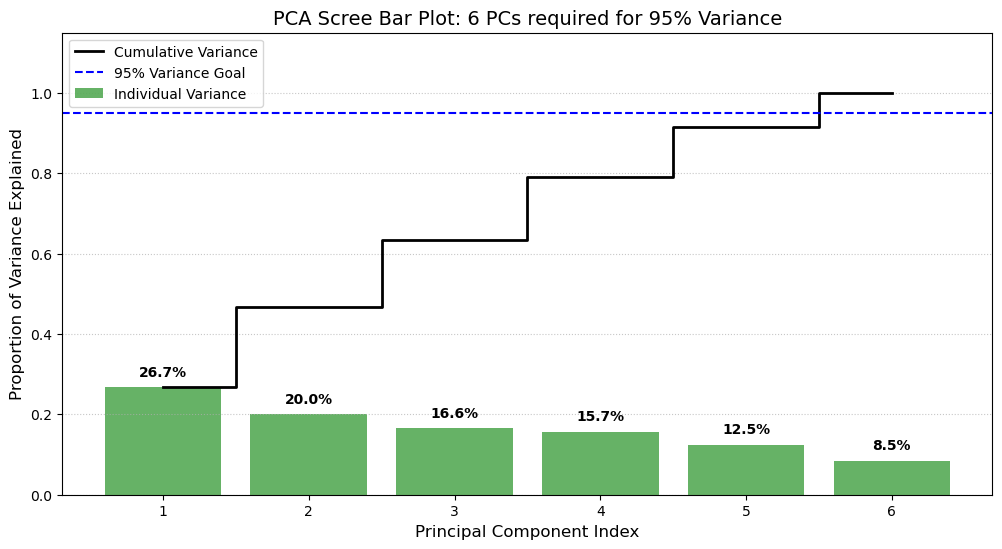

In [31]:
# --- Scree Plot for 95% Cut-off ---

# 1. Determine how many PCs to show (up to 10 or max available)
n_display = min(10, len(exp_var))

# 2. Find the index where cumulative variance first hits 95%
n_95 = np.argmax(cum_var >= 0.95) + 1

# 3. Create a list of colors: Green for 'Keepers', Red for the rest
colors = ['green' if i < n_95 else 'red' for i in range(n_display)]

# 4. Plotting
plt.figure(figsize=(12, 6))

# Plot the bars
bars = plt.bar(range(1, n_display + 1), exp_var[:n_display], 
               color=colors, alpha=0.6, label='Individual Variance')

# --- ADDING PERCENTAGE NUMBERS ON TOP ---
for i, v in enumerate(exp_var[:n_display]):
    plt.text(i + 1, v + 0.02, f"{v*100:.1f}%", 
             ha='center', va='bottom', fontsize=10, fontweight='bold')

# Plot the cumulative staircase
plt.step(range(1, n_display + 1), cum_var[:n_display], 
         where='mid', label='Cumulative Variance', color='black', linewidth=2)

# Add the 95% threshold line
plt.axhline(y=0.95, color='blue', linestyle='--', label='95% Variance Goal')

# Labels and Title
plt.title(f"PCA Scree Bar Plot: {n_95} PCs required for 95% Variance", fontsize=14)
plt.xlabel("Principal Component Index", fontsize=12)
plt.ylabel("Proportion of Variance Explained", fontsize=12)
plt.xticks(range(1, n_display + 1)) 
plt.ylim(0, 1.15) # Increased to make room for labels
plt.legend(loc='upper left')
plt.grid(axis='y', linestyle=':', alpha=0.7)

plt.show()

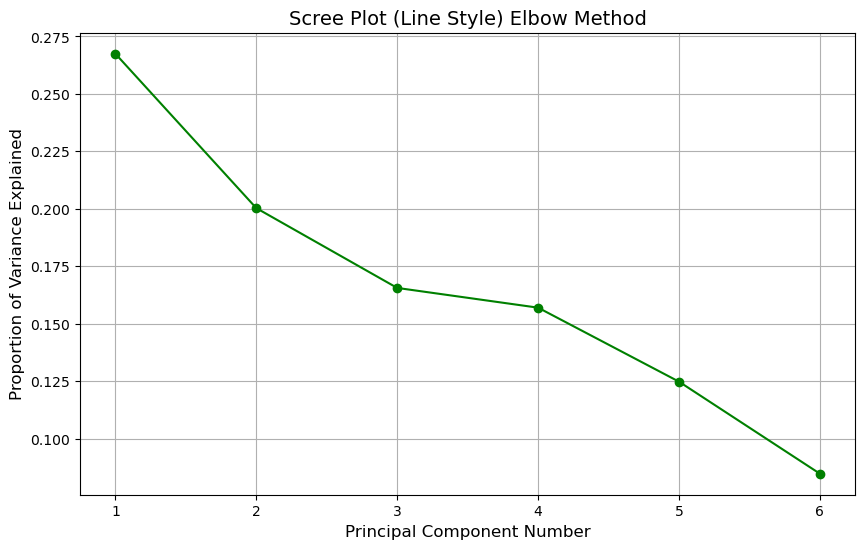

In [32]:
#Scree Plot Line variation - 
PC_number = np.arange(1, len(exp_var) + 1)
plt.figure(figsize=(10,6))
plt.plot(PC_number, exp_var, marker='o', linestyle='-', color='g')
plt.title('Scree Plot (Line Style) Elbow Method', fontsize =14)
plt.xlabel('Principal Component Number', fontsize=12)
plt.ylabel('Proportion of Variance Explained', fontsize=12) 
plt.grid()

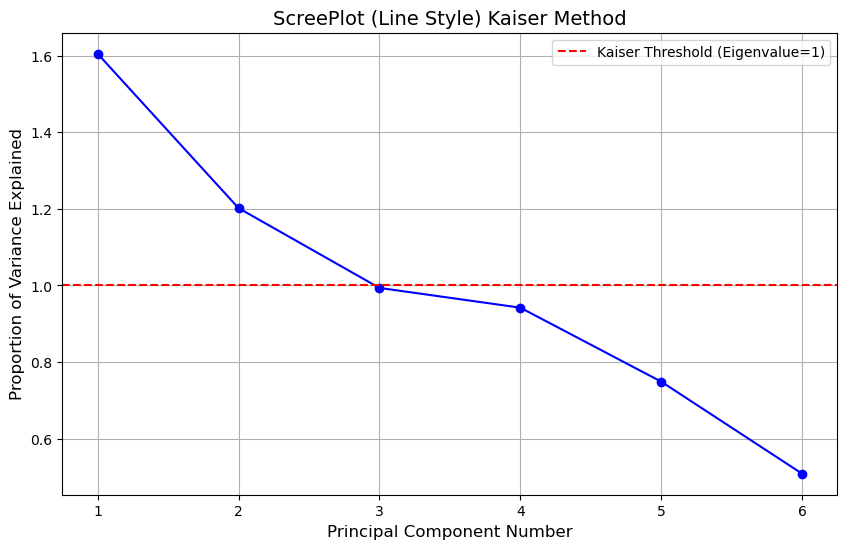

In [36]:
# Kaiser method variation Scree Plot - 
# Works with absolute values while we have been working with proportions of variance explained 
# Here we look at the eigenvalues directly. After scaling all variables have variance 1, after transformation so we look for eigenvalues >1 as variables 
# that now have less than 1 variance are not contributing meaningfully compared to ones with greater than 1. 
eigenvalues = pca.explained_variance_
plt.figure(figsize=(10,6))
plt.plot(PC_number, eigenvalues, marker='o', linestyle='-', color='b')
plt.title('ScreePlot (Line Style) Kaiser Method', fontsize =14)
plt.xlabel('Principal Component Number', fontsize=12)
plt.ylabel('Proportion of Variance Explained', fontsize=12) 
plt.axhline(y= 1, color='r', linestyle='--', label='Kaiser Threshold (Eigenvalue=1)')
plt.legend(loc = 'upper right')
plt.grid()


--- PC1 Composition (Top Contributors) ---
BonusMalus    0.653281
Density       0.119925
VehAge        0.035288
VehPower     -0.085594
Exposure     -0.379844
DrivAge      -0.637173
Name: PC1, dtype: float64

--- PC2 Composition (Top Contributors) ---
VehAge        0.665202
Exposure      0.467584
BonusMalus    0.137448
DrivAge      -0.149333
VehPower     -0.288714
Density      -0.462950
Name: PC2, dtype: float64


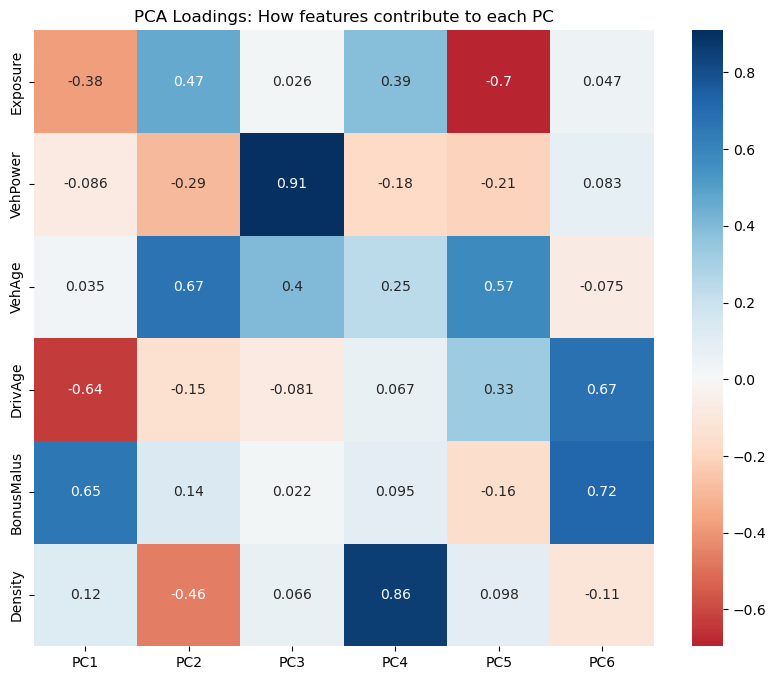

In [ ]:
# Decomposition of Principal Components
# Create a Loadings DataFrame
# This maps your original features back to the Principal Components
loadings = pd.DataFrame(
    pca.components_.T, 
    columns=[f'PC{i+1}' for i in range(len(numeric_cols))],
    index=numeric_cols
)

# 2. Display the "Recipe" for the first two components
print("--- PC1 Composition (Top Contributors) ---")
print(loadings['PC1'].sort_values(ascending=False))

print("\n--- PC2 Composition (Top Contributors) ---")
print(loadings['PC2'].sort_values(ascending=False))

# 3. Visualization: Heatmap of Loadings
import seaborn as sns
plt.figure(figsize=(10, 8))
sns.heatmap(loadings, annot=True, cmap='RdBu', center=0)
plt.title("PCA Loadings: How features contribute to each PC")
plt.show()

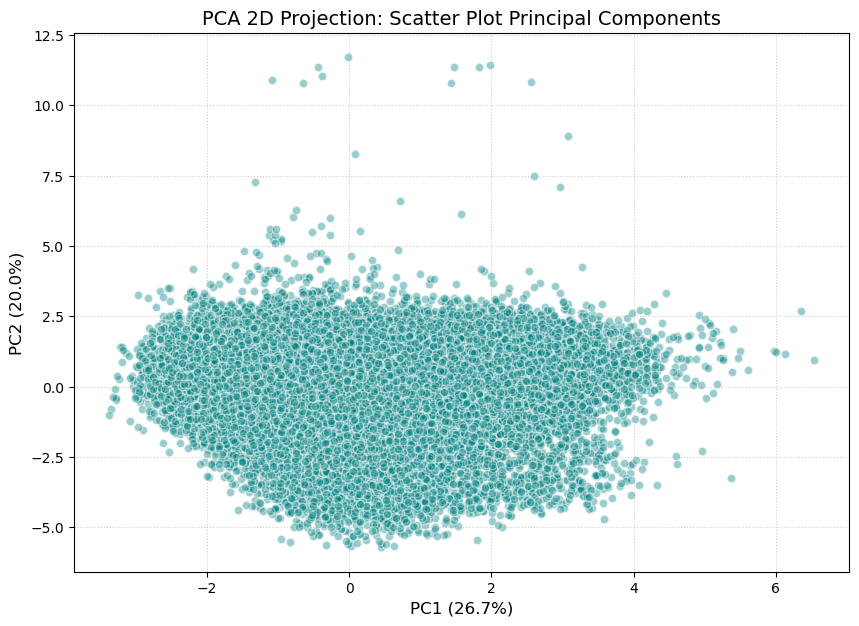

In [46]:
# Create a 2D Scatter Plot of the first two components
plt.figure(figsize=(10, 7))
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], alpha=0.4, c='teal', edgecolors='white')

plt.xlabel(f'PC1 ({exp_var[0]*100:.1f}%)', fontsize=12)
plt.ylabel(f'PC2 ({exp_var[1]*100:.1f}%)', fontsize=12)
plt.title('PCA 2D Projection: Scatter Plot Principal Components', fontsize=14)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

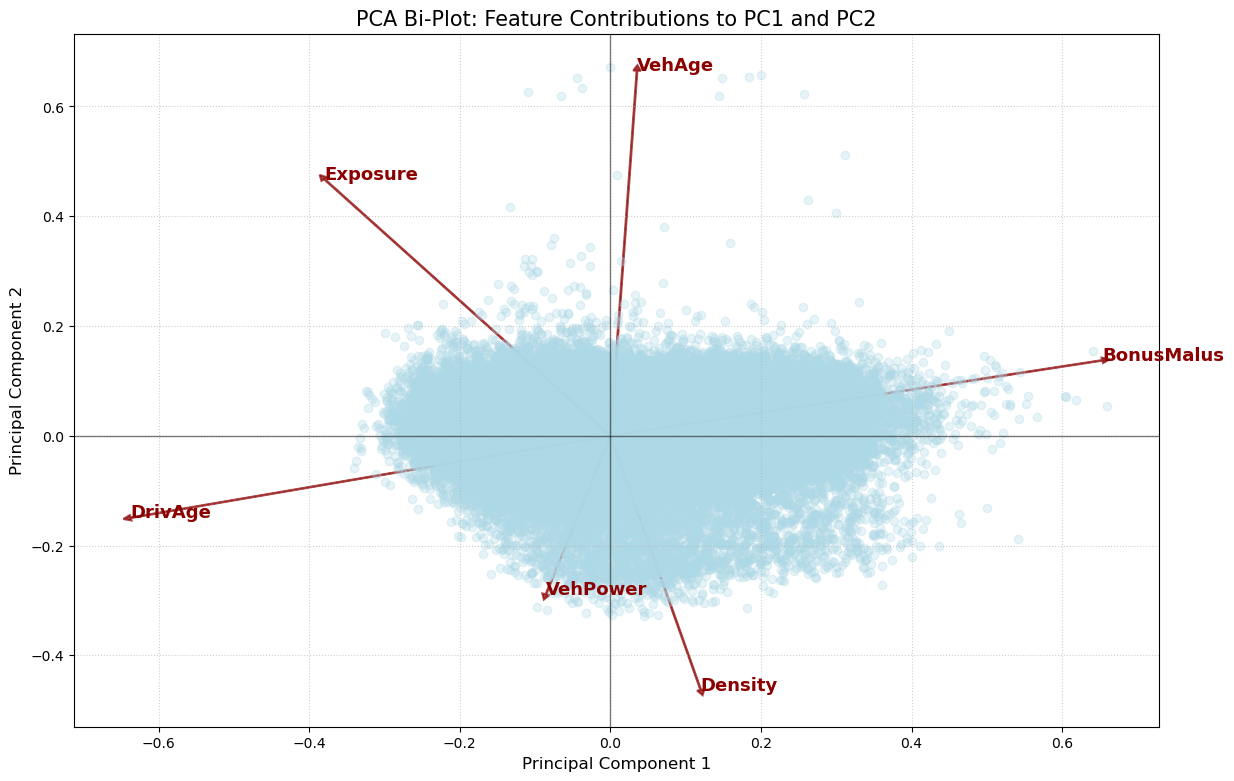

In [45]:
# BI plotting
# 1. Extract first principal component and Second 
PC1 = X_train_pca[:, 0] 
PC2 = X_train_pca[:, 1]

# 2. Scale factor for PC1 and PC2
ScalePC1 = 1.0/(PC1.max() - PC1.min()) 
ScalePC2 = 1.0/(PC2.max() - PC2.min())


# 3. Bi - plot
fig, ax = plt.subplots(figsize = (14, 9))      # Set figure and size

loadings_arr = loadings.values 

for i, feature in enumerate(numeric_cols): 
    # Logic: loadings_arr[i, 0] is the weight of feature 'i' on PC1
    # Logic: loadings_arr[i, 1] is the weight of feature 'i' on PC2
    ax.arrow(0, 0, 
             loadings_arr[i, 0], 
             loadings_arr[i, 1], 
             head_width=0.01, 
             head_length=0.01, 
             linewidth=1.5, 
             color='darkred', 
             alpha=0.7)
    
    # Add labels to the arrows
    ax.text(loadings_arr[i, 0] * 1, 
            loadings_arr[i, 1] * 1, 
            feature, 
            color="darkred", 
            fontsize=13, 
            fontweight='bold')

# 4. Plot the scaled data points (the background dots)
ax.scatter(PC1 * ScalePC1, 
           PC2 * ScalePC2, 
           alpha=0.3, 
           c='lightblue', 
           label='Policies')

# 5. Formatting
ax.set_xlabel("Principal Component 1", fontsize=12)
ax.set_ylabel("Principal Component 2", fontsize=12)
ax.set_title("PCA Bi-Plot: Feature Contributions to PC1 and PC2", fontsize=15)
ax.axhline(0, color='black', linestyle='-', linewidth=1, alpha=0.5)
ax.axvline(0, color='black', linestyle='-', linewidth=1, alpha=0.5)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()


In [ ]:
# Creating Final Handoff Dataset

# Training (fit_transform) phase builds the basis while here, pca.transform just projects the test data onto the prexisting space(basis)
X_test_pca = pca.transform(test_scaled[numeric_cols]) 

# Handoff DataFrames Creation
pca_columns = [f'PC{i+1}' for i in range(n_95)] # Name columns up to n_95 results in list like - ['PC1', 'PC2', ..., 'PCn']
train_pca_df = pd.DataFrame(X_train_pca[:, :n_95], columns=pca_columns) # Create DataFrame with only the selected PCs up till 95 % keep what you need number of PC's
test_pca_df = pd.DataFrame(X_test_pca[:, :n_95], columns=pca_columns)

# 4. Attach Target variables for your teammates
train_pca_df['ClaimNb'] = df['ClaimNb'].values  # HERE I THINK IT WILL BE claimrate but the processed data needs to be applied first. 
#________________________________________________________

train_pca_df.head()

,PC1,PC2,PC3,PC4,PC5,PC6,ClaimNb
0,-0.784845,0.556357,-0.522944,1.125969,-0.485197,-0.503215,0
1,0.561853,0.406958,-0.907152,-0.034322,1.055166,0.057753,0
2,1.258623,-0.214127,-1.523811,-0.512813,-0.709745,-0.059371,0
3,-0.453523,-0.765909,-0.998607,-0.831432,1.045520,0.064220,0
4,0.171572,0.208810,-0.954372,-0.586288,1.489865,-0.622704,0
